In [170]:
import pandas as pd
df=pd.read_excel('../data/online_retail_II.xlsx')

In [171]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [172]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [173]:
df = df.dropna(subset=['Customer ID']) #missing customer id and fixing it

In [174]:
df = df[df['Quantity'] > 0] #removing negative quantity and fixing it

In [175]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate']) #fixing date format

In [176]:
df['Revenue'] = df['Quantity'] * df['Price']

In [177]:
df['Hour'] = df['InvoiceDate'].dt.hour
df['Day'] = df['InvoiceDate'].dt.day_name()
df['Month'] = df['InvoiceDate'].dt.month

In [178]:
df.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Hour,Day,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,7,Tuesday,12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,Tuesday,12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,Tuesday,12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,7,Tuesday,12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,7,Tuesday,12


In [179]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID,Revenue,Hour,Month
count,407695.000000,407695,407695.000000,407695.000000,407695.000000,407695.000000,407695.000000
mean,13.586686,2010-07-01 10:10:10.782177,3.294188,15368.504107,21.663261,12.873972,7.404631
min,1.000000,2009-12-01 07:45:00,0.000000,12346.000000,0.000000,7.000000,1.000000
25%,2.000000,2010-03-26 14:01:00,1.250000,13997.000000,4.950000,11.000000,4.000000
50%,5.000000,2010-07-09 15:46:00,1.950000,15321.000000,11.900000,13.000000,8.000000
75%,12.000000,2010-10-14 17:09:00,3.750000,16812.000000,19.500000,14.000000,11.000000
max,19152.000000,2010-12-09 20:01:00,10953.500000,18287.000000,15818.400000,20.000000,12.000000
std,96.842229,NaN,34.756655,1679.795700,77.147356,2.303918,3.472754


In [180]:
df = df.rename(columns={
    'Invoice': 'order_id',
    'StockCode': 'item_id',
    'Description': 'item_name',
    'Quantity': 'quantity',
    'InvoiceDate': 'order_time',
    'Price': 'price',
    'Customer ID': 'customer_id',
    'Country': 'location'
})

In [181]:
df.head(5)

,order_id,item_id,item_name,quantity,order_time,price,customer_id,location,Revenue,Hour,Day,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,7,Tuesday,12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,Tuesday,12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,Tuesday,12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,7,Tuesday,12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,7,Tuesday,12


In [182]:
df['order_value'] = df['quantity'] * df['price']

In [183]:
df.head(5)

,order_id,item_id,item_name,quantity,order_time,price,customer_id,location,Revenue,Hour,Day,Month,order_value
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,7,Tuesday,12,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,Tuesday,12,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,Tuesday,12,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,7,Tuesday,12,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,7,Tuesday,12,30.0


In [184]:
total_revenue = df['Revenue'].sum()
total_orders = df['order_id'].nunique()

aov = total_revenue / total_orders

print(total_revenue, total_orders, aov)

8832003.274 19215 459.64107593026284


In [185]:
df.groupby('location')['Revenue'].sum().sort_values(ascending=False).head()

location
United Kingdom    7414755.963
EIRE               356085.210
Netherlands        268786.000
Germany            202395.321
France             146215.420
Name: Revenue, dtype: float64

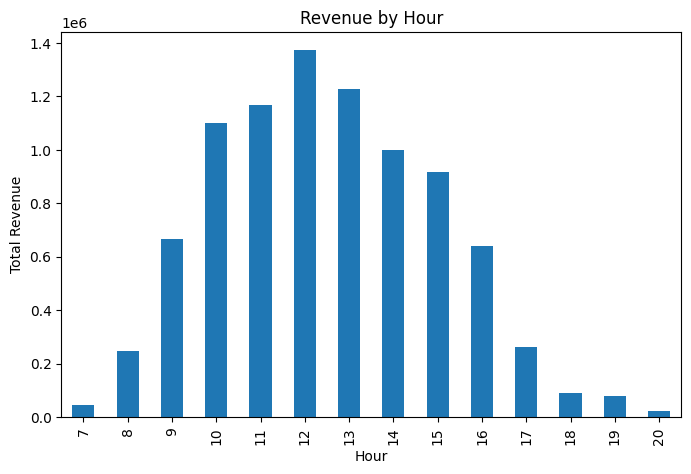

In [234]:
import matplotlib.pyplot as plt

df.groupby('Hour')['Revenue'].sum().plot(kind='bar')
plt.rcParams['figure.figsize'] = (8,5)
plt.xlabel('Hour')
plt.ylabel('Total Revenue')
plt.title('Revenue by Hour')
plt.savefig("../outputs/hourly_demand.png")  # 👈 IMPORTANT

plt.show()

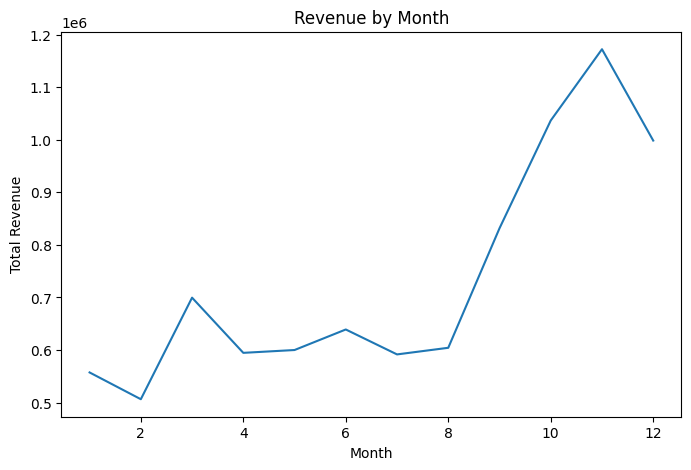

In [233]:
import matplotlib.pyplot as plt
df.groupby('Month')['Revenue'].sum().plot()
plt.rcParams['figure.figsize'] = (8,5)
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.title('Revenue by Month')
plt.savefig("../outputs/monthly_demand.png")  # 👈 IMPORTANT

plt.show()

In [188]:
top_items = df.groupby('item_name')['Revenue'].sum().sort_values(ascending=False).head(10)
top_items

item_name
WHITE HANGING HEART T-LIGHT HOLDER     151624.31
REGENCY CAKESTAND 3 TIER               143893.35
Manual                                  98560.64
ASSORTED COLOUR BIRD ORNAMENT           70493.83
JUMBO BAG RED RETROSPOT                 51759.30
POSTAGE                                 48741.08
ROTATING SILVER ANGELS T-LIGHT HLDR     40186.65
PAPER CHAIN KIT 50'S CHRISTMAS          36933.50
PARTY BUNTING                           35035.90
EDWARDIAN PARASOL NATURAL               34044.75
Name: Revenue, dtype: float64

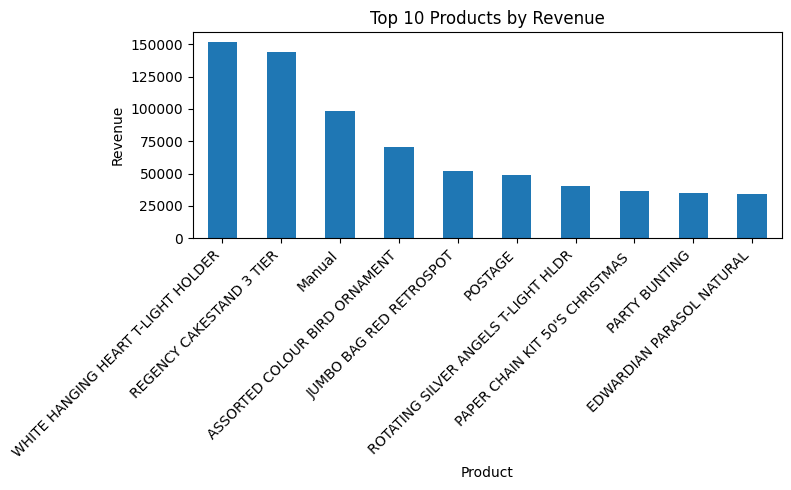

In [232]:
import matplotlib.pyplot as plt
plt.figure()
plt.rcParams['figure.figsize'] = (8,5)
top_items.plot(kind='bar')

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig("../outputs/top_products.png")
plt.show()

In [189]:
df.groupby('item_name')['quantity'].sum().sort_values(ascending=False).head(10)

item_name
WHITE HANGING HEART T-LIGHT HOLDER    56915
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54754
BROCADE RING PURSE                    48166
PACK OF 72 RETRO SPOT CAKE CASES      45156
ASSORTED COLOUR BIRD ORNAMENT         44551
60 TEATIME FAIRY CAKE CASES           35806
PACK OF 60 PINK PAISLEY CAKE CASES    31006
JUMBO BAG RED RETROSPOT               29578
SMALL POPCORN HOLDER                  25718
BLACK AND WHITE PAISLEY FLOWER MUG    25685
Name: quantity, dtype: int64

<Axes: xlabel='quantity', ylabel='Revenue'>

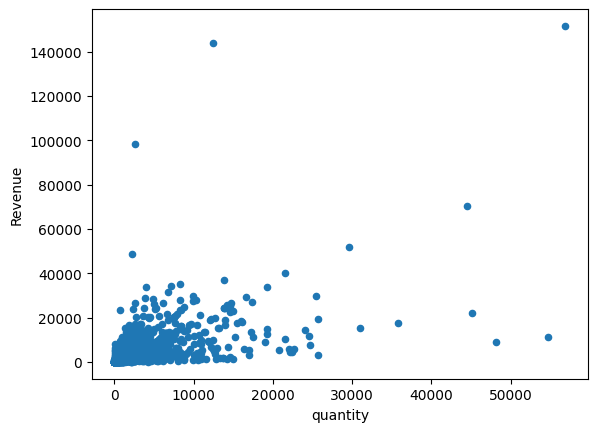

In [190]:
product_analysis = df.groupby('item_name').agg({
    'Revenue': 'sum',
    'quantity': 'sum'
})

product_analysis.plot.scatter(x='quantity', y='Revenue')

In [191]:
customer_data = df.groupby('customer_id').agg({
    'Revenue': 'sum',
    'order_id': 'nunique'
}).rename(columns={'order_id': 'order_count'})

In [192]:
customer_data.sort_values('Revenue', ascending=False).head(10)

,Revenue,order_count
customer_id,,
18102.0,349164.35,89
14646.0,248396.50,78
14156.0,196566.74,102
14911.0,152147.57,205
13694.0,131443.19,94
17511.0,84541.17,31
15061.0,83284.38,86
16684.0,80489.21,27
16754.0,65500.07,29


In [193]:
# Cost (production cost) Create Profit Columns
df['cost'] = df['price'] * 0.6 * df['quantity']

# Commission (platform fee)
df['commission'] = df['Revenue'] * 0.25

# Packaging cost
df['packaging_cost'] = df['quantity'] * 2

# Final profit
df['profit'] = df['Revenue'] - df['cost'] - df['commission'] - df['packaging_cost']

In [194]:
df[['Revenue', 'cost', 'commission', 'profit']].describe()#Validate

,Revenue,cost,commission,profit
count,407695.000000,407695.000000,407695.000000,407695.000000
mean,21.663261,12.997957,5.415815,-23.923883
std,77.147356,46.288413,19.286839,189.182195
min,0.000000,0.000000,0.000000,-38016.720000
25%,4.950000,2.970000,1.237500,-21.030000
50%,11.900000,7.140000,2.975000,-7.545000
75%,19.500000,11.700000,4.875000,-2.215000
max,15818.400000,9491.040000,3954.600000,1641.025000


In [195]:
df.groupby('item_name')[['Revenue','profit']].sum().sort_values('Revenue', ascending=False).head(10) #Profit vs Revenue Analysis

,Revenue,profit
item_name,,
WHITE HANGING HEART T-LIGHT HOLDER,151624.31,-91086.3535
REGENCY CAKESTAND 3 TIER,143893.35,-3419.9975
Manual,98560.64,9522.0960
ASSORTED COLOUR BIRD ORNAMENT,70493.83,-78527.9255
JUMBO BAG RED RETROSPOT,51759.30,-51392.1050
POSTAGE,48741.08,2887.1620
ROTATING SILVER ANGELS T-LIGHT HLDR,40186.65,-37154.0025
PAPER CHAIN KIT 50'S CHRISTMAS,36933.50,-22179.9750
PARTY BUNTING,35035.90,-11376.6150


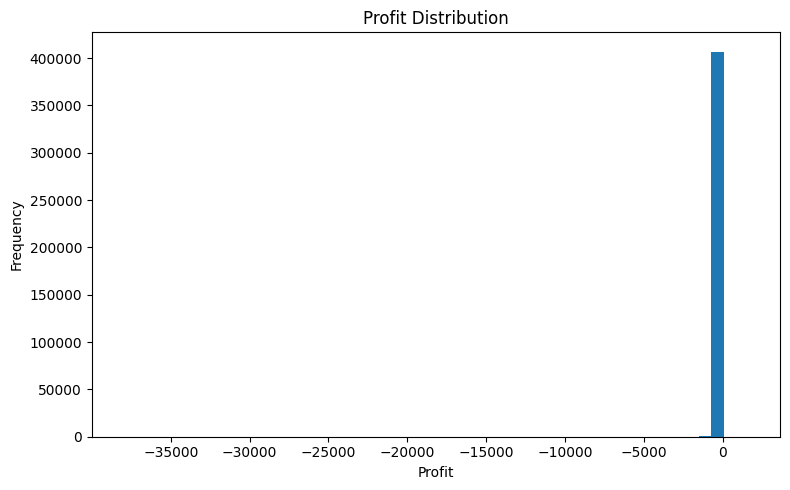

In [231]:
import matplotlib.pyplot as plt

plt.figure()
plt.rcParams['figure.figsize'] = (8,5)
df['profit'].plot(kind='hist', bins=50)

plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("../outputs/profit_distribution.png")
plt.show() #Profit Distribution

In [197]:
loss_items = df.groupby('item_name')['profit'].sum().sort_values().head(10) #Loss-Making Items
loss_items

item_name
WORLD WAR 2 GLIDERS ASSTD DESIGNS    -107810.0570
BROCADE RING PURSE                    -95004.8510
WHITE HANGING HEART T-LIGHT HOLDER    -91086.3535
PACK OF 72 RETRO SPOT CAKE CASES      -87034.0380
ASSORTED COLOUR BIRD ORNAMENT         -78527.9255
60 TEATIME FAIRY CAKE CASES           -68986.5200
PACK OF 60 PINK PAISLEY CAKE CASES    -59746.4375
JUMBO BAG RED RETROSPOT               -51392.1050
BLACK AND WHITE PAISLEY FLOWER MUG    -50917.0645
SMALL POPCORN HOLDER                  -48506.3560
Name: profit, dtype: float64

In [198]:
df.groupby('item_name')['profit'].sum().sort_values(ascending=False).head(10)  #Profit by Product

item_name
Manual                                 9522.0960
POSTAGE                                2887.1620
SET/4 WHITE RETRO STORAGE CUBES        2187.8750
VINTAGE POST OFFICE CABINET             947.2305
VINTAGE BLUE KITCHEN CABINET            802.7500
CARRIAGE                                676.5000
VINTAGE RED KITCHEN CABINET             676.0000
HALL CABINET WITH 3 DRAWERS             355.0535
SET 3 WICKER LOG BASKETS                306.0075
Adjustment by john on 26/01/2010 16     280.1115
Name: profit, dtype: float64

In [199]:
# Try lower commission scenario (15%)
df['profit_low_commission'] = df['Revenue'] - df['cost'] - (df['Revenue'] * 0.15) - df['packaging_cost']

df['profit_low_commission'].mean()

np.float64(-21.757556951888052)

In [200]:
df['profit_margin'] = df['profit'] / df['Revenue']

In [201]:
df['profit_margin'].describe()

c:\Users\tanus\OneDrive\Restaurant-project\.venv\Lib\site-packages\pandas\core\nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    4.076950e+05
mean             -inf
std               NaN
min              -inf
25%     -1.450000e+00
50%     -8.756410e-01
75%     -3.833333e-01
max      1.498174e-01
Name: profit_margin, dtype: float64

In [202]:
df.groupby('item_name')[['Revenue','profit']].sum().sort_values('profit', ascending=False).head() #top profitable items

,Revenue,profit
item_name,,
Manual,98560.64,9522.0960
POSTAGE,48741.08,2887.1620
SET/4 WHITE RETRO STORAGE CUBES,23252.50,2187.8750
VINTAGE POST OFFICE CABINET,7954.87,947.2305
VINTAGE BLUE KITCHEN CABINET,5605.00,802.7500


In [203]:
customer_data = df.groupby('customer_id').agg({
    'Revenue': 'sum',
    'profit': 'sum',
    'order_id': 'nunique',
    'location': 'first'
}).rename(columns={'order_id': 'order_count'})

In [204]:
customer_data['profit_margin'] = customer_data['profit'] / customer_data['Revenue']

In [205]:
customer_data['segment'] = pd.qcut(customer_data['Revenue'], 3, labels=['Low', 'Medium', 'High'])

In [206]:
customer_data.groupby('segment')[['Revenue','profit','order_count']].mean()

,Revenue,profit,order_count
segment,,,
Low,220.900675,-235.684092,1.309458
Medium,747.774313,-771.003533,2.753825
High,5173.190988,-5776.099238,9.299026


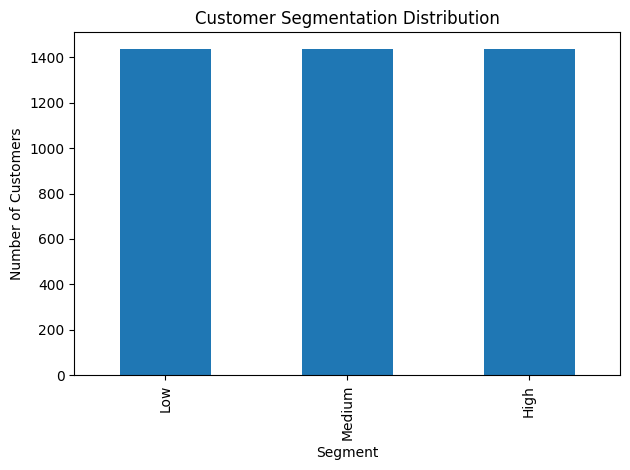

In [230]:
import matplotlib.pyplot as plt

segment_counts = customer_data['segment'].value_counts()

plt.figure()
plt.rcParams['figure.figsize'] = (8,5)
segment_counts.plot(kind='bar')

plt.title("Customer Segmentation Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig("../outputs/customer_segments.png")
plt.show()

In [207]:
# High revenue but loss-making
customer_data[(customer_data['Revenue'] > customer_data['Revenue'].quantile(0.7)) & 
              (customer_data['profit'] < 0)].head(10)

,Revenue,profit,order_count,location,profit_margin,segment
customer_id,,,,,,
12349.0,2671.14,-1585.3290,3,Italy,-0.593503,High
12356.0,3562.25,-3117.6625,3,Portugal,-0.875195,High
12357.0,12079.99,-5946.0015,2,Switzerland,-0.492219,High
12358.0,2719.01,-1254.1485,3,Austria,-0.461252,High
12359.0,2563.36,-1875.4960,6,Cyprus,-0.731655,High
12360.0,1590.83,-2349.3755,5,Austria,-1.476824,High
12369.0,1791.15,-2213.3275,3,Austria,-1.235702,High
12371.0,2179.42,-1363.0870,3,Switzerland,-0.625436,High
12374.0,2246.29,-1703.0565,3,Austria,-0.758164,High


In [208]:
customer_data['segment'].value_counts()

segment
Low       1438
Medium    1438
High      1438
Name: count, dtype: int64

In [209]:
customer_data.groupby('segment')['Revenue'].sum()

segment
Low        317655.171
Medium    1075299.462
High      7439048.641
Name: Revenue, dtype: float64

In [210]:
#average order value
customer_data['avg_order_value'] = customer_data['Revenue'] / customer_data['order_count']

In [211]:
#total quantity purchased
quantity_data = df.groupby('customer_id')['quantity'].sum()
customer_data = customer_data.merge(quantity_data, on='customer_id')

In [212]:
#average price paid
customer_data['avg_price'] = customer_data['Revenue'] / customer_data['quantity']

In [213]:
#recency
df['order_id'] = pd.to_datetime(df['order_id'])

last_date = df['order_id'].max()

recency = df.groupby('customer_id')['order_id'].max().apply(lambda x: (last_date - x).days)

customer_data = customer_data.merge(recency.rename('recency'), on='customer_id')

In [214]:
#country
customer_data = pd.get_dummies(customer_data, columns=['location'], drop_first=True)

In [215]:
# -------------------------------
# Machine Learning (Profitability Prediction)
# -------------------------------

"""
Objective:
Predict whether a customer is profitable or loss-making
based on revenue and order behavior.

This model supports earlier insights that high-revenue customers
are not always profitable.
"""

'\nObjective:\nPredict whether a customer is profitable or loss-making\nbased on revenue and order behavior.\n\nThis model supports earlier insights that high-revenue customers\nare not always profitable.\n'

In [216]:
#create target variable
customer_data['is_profitable'] = customer_data['profit'].apply(lambda x: 1 if x > 0 else 0)

In [217]:
#select features and target
X = customer_data[['Revenue', 'order_count', 'recency']]
y = customer_data['is_profitable']

In [218]:
#train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [219]:
#train model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [220]:
#evaluate model
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      1.00      0.99       855
           1       0.00      0.00      0.00         8

    accuracy                           0.99       863
   macro avg       0.50      0.50      0.50       863
weighted avg       0.98      0.99      0.99       863



In [221]:
#feature importance
pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
})

,Feature,Importance
0,Revenue,0.000174
1,order_count,-0.701979
2,recency,0.000000


In [222]:
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [223]:
from sklearn.metrics import confusion_matrix
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))


[[494 361]
 [  0   8]]


In [224]:
#evaluate model
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.58      0.73       855
           1       0.02      1.00      0.04         8

    accuracy                           0.58       863
   macro avg       0.51      0.79      0.39       863
weighted avg       0.99      0.58      0.73       863

